In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import numpy as np

db = mysql.connector.connect(host = 'localhost',
                             username = 'root',
                             password = '1234',
                             database = 'ecommerce')
cur = db.cursor()

#  List all unique cities where customers are located 


In [2]:
query = ''' select distinct customer_city from customers'''

cur.execute(query)
data = cur.fetchall()
data

[('franca',),
 ('sao bernardo do campo',),
 ('sao paulo',),
 ('mogi das cruzes',),
 ('campinas',),
 ('jaragua do sul',),
 ('timoteo',),
 ('curitiba',),
 ('belo horizonte',),
 ('montes claros',),
 ('rio de janeiro',),
 ('lencois paulista',),
 ('caxias do sul',),
 ('piracicaba',),
 ('guarulhos',),
 ('pacaja',),
 ('florianopolis',),
 ('aparecida de goiania',),
 ('santo andre',),
 ('goiania',),
 ('cachoeiro de itapemirim',),
 ('sao jose dos campos',),
 ('sao roque',),
 ('camacari',),
 ('resende',),
 ('sumare',),
 ('novo hamburgo',),
 ('sao luis',),
 ('sao jose',),
 ('santa barbara',),
 ('ribeirao preto',),
 ('ituiutaba',),
 ('taquarituba',),
 ('sao jose dos pinhais',),
 ('barrinha',),
 ('parati',),
 ('dourados',),
 ('trindade',),
 ('cascavel',),
 ('fortaleza',),
 ('brasilia',),
 ('pelotas',),
 ('porto alegre',),
 ('salto',),
 ('jundiai',),
 ('cacapava',),
 ('sao vicente',),
 ('uberlandia',),
 ('botelhos',),
 ('sao goncalo',),
 ('araucaria',),
 ('nova iguacu',),
 ('areia branca',),
 ('campo

 # Count the number of orders placed in 2017  .

In [3]:
query = '''select count(order_id) from orders 
           where year(order_purchase_timestamp) = 2017'''
cur.execute(query)
data = cur.fetchall()
'total orders placed in 2017 are',data[0][0]

('total orders placed in 2017 are', 270606)

# Find the total sales per category .

In [4]:
query = ''' select products.product_category category,sum(payments.payment_value) sales from products 
           join order_items on products.product_id = order_items.product_id
           join payments on payments.order_id = order_items.order_id
           group by category
           '''
cur.execute(query)
data = cur.fetchall()
data

[('perfumery', 16215637.116611004),
 ('Furniture Decoration', 45765644.536851704),
 ('telephony', 15580225.622803986),
 ('bed table bath', 54801717.47210455),
 ('automotive', 27273418.5960083),
 ('computer accessories', 50730574.28026527),
 ('housewares', 35032260.16908437),
 ('babies', 17275061.111520767),
 ('toys', 19809206.063340485),
 ('Furniture office', 20698447.588752747),
 ('Cool Stuff', 24950336.001557827),
 ('HEALTH BEAUTY', 53035939.820593834),
 ('pet Shop', 9960607.049645424),
 ('General Interest Books', 2070232.3076934814),
 ('stationary store', 10158082.2290802),
 ('Watches present', 45734933.71495867),
 ('PCs', 8931889.579711914),
 ('climatization', 2917461.10357666),
 ('Construction Tools Construction', 7727220.168281555),
 ('sport leisure', 44548081.892784715),
 ('Bags Accessories', 5988841.292321205),
 ('electronics', 8315427.189572275),
 ('Casa Construcao', 4372649.289809227),
 ('Games consoles', 6255372.132011414),
 ('Fashion Bags and Accessories', 6981064.960708618

# Count the number of customers from each state .

<function matplotlib.pyplot.show(close=None, block=None)>

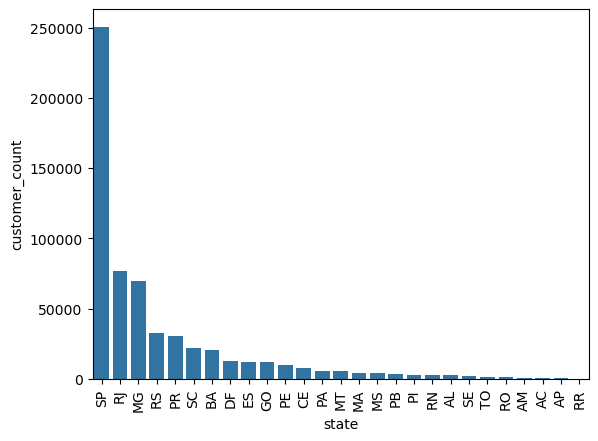

In [5]:
query = '''select customer_state, count(customer_id)
from customers
group by customer_state
'''
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns = ['state','customer_count'])
df = df.sort_values(by = 'customer_count',ascending = False)
sns.barplot(x=df['state'],y=df['customer_count'],data = df)
plt.xticks(rotation = 90)
plt.show


# Calculate the percentage of orders that were paid in installments .

In [6]:
query = ''' select (sum(case when payment_installments > 1 then 1 else 0 end))/count(*)*100 from payments'''
cur.execute(query)
data = cur.fetchall()
data

[(Decimal('49.4176'),)]

# Calculate the number of orders per month in 2018 .

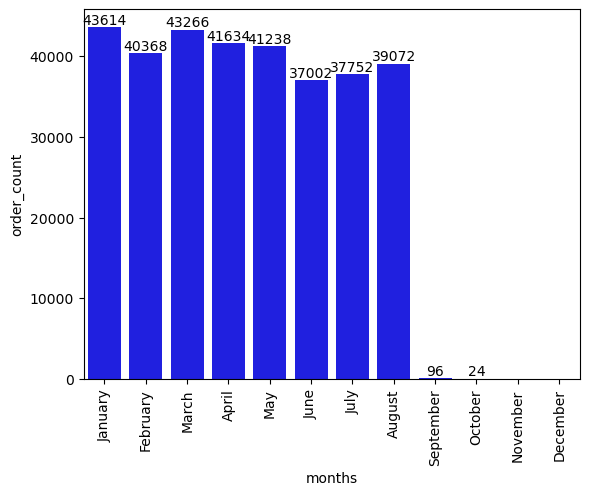

<Figure size 2000x800 with 0 Axes>

In [7]:
query = ''' select monthname(order_purchase_timestamp) months,count(order_id) from orders order_count
where year(order_purchase_timestamp) = 2018
group by months
'''
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns = ['months','order_count'])
o = ['January','February','March','April','May','June','July','August','September','October','November','December']
ax = sns.barplot(x = df['months'],y = df['order_count'],data=df, order = o,color = 'blue')
plt.xticks(rotation =90)
ax.bar_label(ax.containers[0])
plt.figure(figsize=(20,8))
plt.show()


# Find the average number of products per order, grouped by customer city  .


In [8]:
query = '''
with count_per_order as
(select orders.order_id,orders.customer_id,count(order_items.order_id) as oc from orders
join order_items on orders.order_id = order_items.order_id
group by orders.order_id,orders.customer_id)

select customers.customer_city,round(avg(count_per_order.oc),2) average_orders from customers 
join count_per_order on customers.customer_id = count_per_order.customer_id
group by  customers.customer_city order by average_orders desc
'''
cur.execute(query)
data  = cur.fetchall()
df = pd.DataFrame(data,columns = ["customer city","average order"])
df.head(10)

,customer city,average order
0,padre carvalho,84.00
1,celso ramos,78.00
2,datas,72.00
3,candido godoi,72.00
4,matias olimpio,60.00
5,cidelandia,48.00
6,curralinho,48.00
7,picarra,48.00
8,morro de sao paulo,48.00
9,teixeira soares,48.00


# Calculate the percentage of total revenue contributed by each product category .

In [9]:
query = '''
select upper(products.product_category) category,round((sum(payments.payment_value)/(select sum(payments.payment_value) from payments))*100,2) sales_percentage from products 
join order_items on products.product_id = order_items.product_id
join payments on payments.order_id = order_items.order_id
group by category order by sales_percentage desc
'''
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns = ['category','percentage distribution'])
df.head()

,category,percentage distribution
0,BED TABLE BATH,85.58
1,HEALTH BEAUTY,82.82
2,COMPUTER ACCESSORIES,79.22
3,FURNITURE DECORATION,71.47
4,WATCHES PRESENT,71.42


# Identify the correlation between product price and the number of times a product has been purchased 

In [10]:
query = '''
select products.product_category,count(order_items.product_id),avg(order_items.price) from products
join order_items on products.product_id = order_items.product_id
group by  products.product_category
'''
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns = ['category','order_count','price'])
arr1 = df['order_count']
arr2 = df['price']
np.corrcoef(arr1,arr2)

array([[ 1.        , -0.10631552],
       [-0.10631552,  1.        ]])

# Calculate the total revenue generated by each seller, and rank them by revenue .

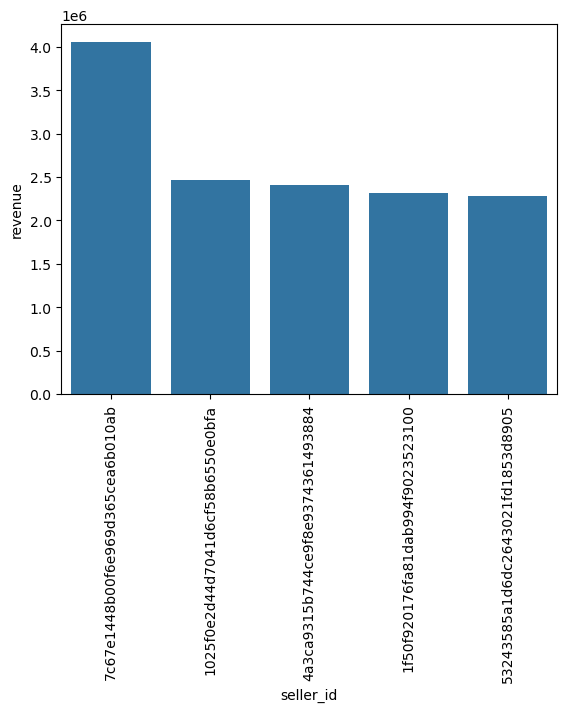

In [11]:
query = '''select *,dense_rank() over(order by revenue desc) as rn from
(select order_items.seller_id,sum(payments.payment_value) revenue from order_items
join payments on order_items.order_id = payments.order_id
group by order_items.seller_id) as a'''
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns = ['seller_id','revenue','rank'])
df = df.head()
sns.barplot(x = 'seller_id',y = 'revenue',data = df)
plt.xticks(rotation = 90)
plt.show()

# Calculate the moving average of order values for each customer over their order history 

In [12]:
query = '''
select customer_id,order_purchase_timestamp,payment,
avg(payment) over(partition by customer_id order by order_purchase_timestamp
rows between 2 preceding and current row) as mov_avg
from
(select orders.customer_id,orders.order_purchase_timestamp,payments.payment_value as payment
from payments join orders
on payments.order_id = orders.order_id) as a
'''
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data)
df

,0,1,2,3
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
2,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
3,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
4,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
...,...,...,...,...
2493259,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001
2493260,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001
2493261,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001
2493262,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001


# Calculate the cumulative sales per month for each year.

In [13]:
query = '''
select years,months,payment,sum(payment)
over(order by years,months) cumulative_sales from
(select year(orders.order_purchase_timestamp) as years, month(orders.order_purchase_timestamp) as months,
round(sum(payments.payment_value),2) as payment
from orders join payments on orders.order_id = payments.order_id
group by years,months
order by years,months) as a;
'''
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data)
df

,0,1,2,3
0,2016,9,6053.76,6.053760e+03
1,2016,10,1418171.52,1.424225e+06
2,2016,12,470.88,1.424696e+06
3,2017,1,3323712.96,4.748409e+06
4,2017,2,7005792.23,1.175420e+07
5,2017,3,10796726.39,2.255093e+07
6,2017,4,10026912.71,3.257784e+07
7,2017,5,14230051.68,4.680789e+07
8,2017,6,12270633.13,5.907853e+07
9,2017,7,14217190.07,7.329572e+07


# Calculate the year-over-year growth rate of total sales

In [21]:
query = '''
with a as(select year(orders.order_purchase_timestamp) as years,
round(sum(payments.payment_value),2) as payment
from orders join payments on orders.order_id = payments.order_id
group by years
order by years)

select years,((payment - lag(payment,1) over(order by years))/lag(payment,1) over(order by years))*100 from a
'''
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ['years','yoy % growth'])
df

,years,yoy % growth
0,2016,NaN
1,2017,12112.703759
2,2018,20.000924
